# AI Decision Engine for Auckland Public Transport

This notebook implements the operational decision-support layer of the AI-driven transport delay prediction system.

The module converts predicted transport delay risks into operational recommendations such as monitoring, headway adjustment, standby bus deployment, and route intervention.

The outputs generated in this notebook will later be used for dashboard visualization and SUMO scenario validation.

In [2]:
# Imports

import pandas as pd
import numpy as np

In [3]:
# Load dataset

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

dataset_path = PROJECT_ROOT / "data" / "raw" / "modeling" / "public_transport_delays.csv"

df = pd.read_csv(dataset_path)

print(df.shape)

df.head()

(2000, 24)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,None,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,None,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,None,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,None,500,46,0,0,6,Spring,1


In [4]:
# Create delay risk categories

def classify_delay_risk(delay):

    if delay <= 5:
        return "Low"

    elif delay <= 15:
        return "Medium"

    elif delay <= 25:
        return "High"

    else:
        return "Severe"


df["delay_risk"] = df["actual_arrival_delay_min"].apply(classify_delay_risk)

df["delay_risk"].value_counts()

Medium    636
High      627
Low       501
Severe    236
Name: delay_risk, dtype: int64

In [5]:
# Decision engine rules

def recommend_action(risk):

    if risk == "Low":
        return "No operational action required"

    elif risk == "Medium":
        return "Monitor route conditions"

    elif risk == "High":
        return "Adjust service headway"

    else:
        return "Deploy standby bus"


df["recommended_action"] = df["delay_risk"].apply(recommend_action)

df[
    [
        "route_id",
        "actual_arrival_delay_min",
        "delay_risk",
        "recommended_action"
    ]
].head(10)

,route_id,actual_arrival_delay_min,delay_risk,recommended_action
0,Route_15,3,Low,No operational action required
1,Route_12,9,Medium,Monitor route conditions
2,Route_16,0,Low,No operational action required
3,Route_19,10,Medium,Monitor route conditions
4,Route_8,14,Medium,Monitor route conditions
5,Route_17,4,Low,No operational action required
6,Route_5,28,Severe,Deploy standby bus
7,Route_16,23,High,Adjust service headway
8,Route_6,19,High,Adjust service headway
9,Route_8,3,Low,No operational action required


In [6]:
# Recommendation distribution

decision_summary = (
    df["recommended_action"]
    .value_counts()
    .reset_index()
)

decision_summary.columns = [
    "recommended_action",
    "count"
]

decision_summary

,recommended_action,count
0,Monitor route conditions,636
1,Adjust service headway,627
2,No operational action required,501
3,Deploy standby bus,236


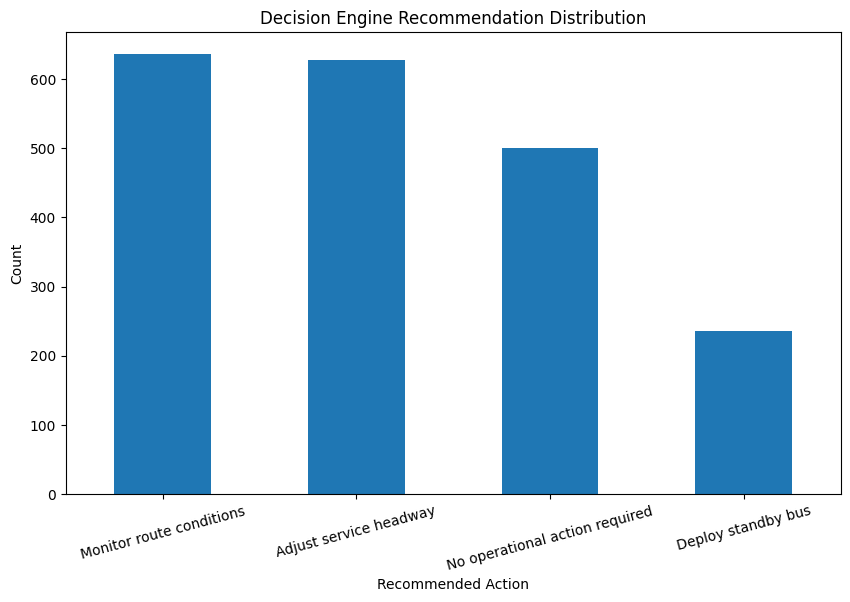

In [7]:
# Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["recommended_action"].value_counts().plot(
    kind="bar"
)

plt.title("Decision Engine Recommendation Distribution")

plt.xlabel("Recommended Action")

plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

In [8]:
# Prepare SUMO scenario export

sumo_export_df = df[
    [
        "route_id",
        "trip_id",
        "actual_arrival_delay_min",
        "delay_risk",
        "recommended_action",
        "weather_condition",
        "traffic_congestion_index"
    ]
]

print(sumo_export_df.shape)

sumo_export_df.head()

(2000, 7)


,route_id,trip_id,actual_arrival_delay_min,delay_risk,recommended_action,weather_condition,traffic_congestion_index
0,Route_15,T00000,3,Low,No operational action required,Storm,81
1,Route_12,T00001,9,Medium,Monitor route conditions,Rain,53
2,Route_16,T00002,0,Low,No operational action required,Clear,67
3,Route_19,T00003,10,Medium,Monitor route conditions,Clear,84
4,Route_8,T00004,14,Medium,Monitor route conditions,Snow,46


In [9]:
# Save decision engine output

output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "decision_engine_output.csv"
)

sumo_export_df.to_csv(
    output_path,
    index=False
)

print("Decision engine output saved successfully.")

Decision engine output saved successfully.
